# Financial Complaint Auto-Routing with NLP

## 1. Project Overview

Assignment 1 proposed a machine-learning system that routes consumer financial complaints to the appropriate product team. The complaint narrative is the only predictor, and the CFPB product category is the target. The final task is an eight-class text-classification problem.

The goal is to demonstrate a reproducible end-to-end **machine-learning prototype**. The system does not make legal or factual decisions, replace human review, or claim production readiness. All reported results are based on the 2024 CFPB dataset.

The notebook is standalone. It prepares the modeling data from a validated 2024 CFPB raw-input CSV using a local-first, download-if-missing workflow. It does not depend on notebooks 01–05, processed datasets, or previously saved model artifacts. The protected 2025 dataset is not used.

### Changes After Data Exploration

The original complaint-routing objective remained unchanged, but data exploration refined the implementation. The final scope was limited to eight product categories with enough observations for modeling. The preprocessing strategy changed from aggressive cleaning to light cleaning that preserves more of the original language. After duplicate-text leakage was discovered, the original row-level split was replaced with conflicting-label removal, same-label duplicate remediation, and group-aware splitting.

## 2. Imports and Configuration

Paths are resolved from the repository structure with `pathlib`; no machine-specific path is hardcoded. Random seeds, folds, category scope, and output paths are centralized below for reproducibility.

### Environment Requirements

- Python 3.10 or later
- Saved outputs verified with Python 3.11.15, NumPy 2.4.6, pandas 3.0.3, requests 2.34.2, chardet 5.2.0, matplotlib 3.10.9, seaborn 0.13.2, and scikit-learn 1.9.0

Required packages: `pandas`, `numpy`, `requests`, `chardet`, `matplotlib`, `seaborn`, `scikit-learn`, and `jupyter`. Install them before running the notebook; the notebook does not install packages automatically.

```bash
pip install pandas numpy requests chardet matplotlib seaborn scikit-learn jupyter
```

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import math
import platform
import re
import textwrap
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

def find_project_root(start_path: Path) -> Path:
    """Locate a full repository or choose a usable standalone project root."""
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        has_notebooks_directory = (candidate / "notebooks").is_dir()
        has_gitignore = (candidate / ".gitignore").is_file()
        if has_notebooks_directory and has_gitignore:
            return candidate

    if current.name.lower() == "notebooks":
        return current.parent
    return current

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_2024_PATH = RAW_DIR / "cfpb_complaints_2024_raw.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_COMPARISON_PATH = FIGURES_DIR / "final_model_comparison.png"
CONFUSION_MATRIX_PATH = FIGURES_DIR / "final_confusion_matrix.png"
INPUT_FILES_USED = (RAW_2024_PATH,)
DOWNLOAD_IF_MISSING = True
FORCE_DOWNLOAD = False
DOWNLOAD_YEAR = 2024
DOWNLOAD_ROWS = 50_000
DOWNLOAD_PAGE_SIZE = 1_000

TEXT_COLUMN = "complaint_what_happened"
TARGET_COLUMN = "product"
LOCKED_CATEGORIES = (
    "Credit reporting or other personal consumer reports",
    "Debt collection",
    "Credit card",
    "Checking or savings account",
    "Mortgage",
    "Money transfer, virtual currency, or money service",
    "Student loan",
    "Vehicle loan or lease",
)
SHORT_COMPLAINT_WORDS = 5
LONG_COMPLAINT_WORDS = 2_000
OUTER_SPLITS = 5
DEVELOPMENT_CV_SPLITS = 5
TUNING_CV_SPLITS = 3
FINAL_TEST_FOLD = 0
RANDOM_STATE = 42
N_JOBS = 1

assert RAW_2024_PATH.name == "cfpb_complaints_2024_raw.csv"
assert all("2024" in path.name and "2025" not in path.name for path in INPUT_FILES_USED)
RAW_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Configured input: {RAW_2024_PATH.relative_to(PROJECT_ROOT)}")
print(f"Locked categories: {len(LOCKED_CATEGORIES)}")
print(f"Parallel jobs: {N_JOBS}")
print(
    f"Data acquisition: DOWNLOAD_IF_MISSING={DOWNLOAD_IF_MISSING}, "
    f"FORCE_DOWNLOAD={FORCE_DOWNLOAD}, year={DOWNLOAD_YEAR}, rows={DOWNLOAD_ROWS:,}"
)
print(f"Python: {platform.python_version()} | scikit-learn: {sklearn.__version__} | pandas: {pd.__version__}")
print("Protected 2025 data is not configured, accessed, or used.")

Project root: E:\MGA\ITEC6740\Final-Project\financial-complaint-auto-routing-nlp
Configured input: data\raw\cfpb_complaints_2024_raw.csv
Locked categories: 8
Parallel jobs: 1
Data acquisition: DOWNLOAD_IF_MISSING=True, FORCE_DOWNLOAD=False, year=2024, rows=50,000
Python: 3.11.15 | scikit-learn: 1.9.0 | pandas: 3.0.3
Protected 2025 data is not configured, accessed, or used.


## 3. Data Acquisition, Loading, and Validation

**Local-first workflow.** The notebook first checks for `data/raw/cfpb_complaints_2024_raw.csv`. When the file exists and `FORCE_DOWNLOAD=False`, it validates and uses the local file without making an API request. When the file is missing and `DOWNLOAD_IF_MISSING=True`, the embedded acquisition code constructs a 50,000-row 2024 CFPB sample using the documented monthly-balanced and daily-stratified sampling procedure, saves it locally, validates it, and continues automatically.

**Reproducibility.** The saved notebook outputs were produced with the frozen 2024 sample used during project development. Because the public CFPB database may change, a later API download may produce a different sample and slightly different metrics. The notebook records the CSV's SHA-256 fingerprint so the exact input used for a run can be identified. It does not automatically compare the fingerprint with a fixed expected checksum.

**Input eligibility.** The CFPB database may contain records without usable narratives or product labels. Before saving the project input, the acquisition step requires a usable narrative, a usable product label, a valid 2024 `date_received`, and a non-empty `complaint_id`. Therefore, the later zero missing-value counts describe the validated project input rather than the entire CFPB database. Original CFPB API columns are retained in the raw CSV, but only the narrative and product fields enter the model.

### CFPB Data-Acquisition Helper Functions

The next code cell contains the standalone acquisition and validation functions. It preserves the original API fields, removes duplicate complaint IDs, handles API failures, and applies the documented sampling procedure. The cell remains visible for inspection and may be manually collapsed in notebook interfaces that support code folding.

In [2]:
CFPB_BASE_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"
CFPB_REQUEST_HEADERS = {
    "User-Agent": "financial-complaint-auto-routing-nlp/1.0 (educational ML project)"
}
CFPB_REQUIRED_COLUMNS = (
    "complaint_what_happened",
    "product",
    "date_received",
    "complaint_id",
)
CFPB_TRANSIENT_STATUS_CODES = {429, 500, 502, 503, 504}
CFPB_REQUEST_TIMEOUT_SECONDS = 30
CFPB_MAX_RETRIES = 4
CFPB_BACKOFF_SECONDS = 1.0
CFPB_REQUEST_PACING_SECONDS = 0.10
CFPB_MAX_PAGES_PER_DAY = 10

def _utc_now_iso() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()

def _parse_cfpb_dates(values: pd.Series) -> pd.Series:
    """Parse CFPB dates and normalize them to timezone-naive UTC."""
    return pd.to_datetime(values, errors="coerce", utc=True).dt.tz_convert(None)

def _complaint_id_keys(df: pd.DataFrame) -> pd.Series:
    """Return normalized complaint-ID keys for validation and deduplication."""
    return df["complaint_id"].fillna("").astype(str).str.strip()

def _build_monthly_targets(year: int, total_rows: int) -> list[dict]:
    """Allocate a nearly equal target to each calendar month."""
    if year != 2024:
        raise ValueError("This notebook is restricted to calendar year 2024.")
    if total_rows <= 0:
        raise ValueError("total_rows must be positive.")

    per_month = math.ceil(total_rows / 12)
    remaining = total_rows
    targets = []
    for month in range(1, 13):
        start = pd.Timestamp(year=year, month=month, day=1)
        end = start + pd.offsets.MonthEnd(0)
        month_rows = remaining if month == 12 else min(per_month, remaining)
        targets.append(
            {
                "month": f"{year}-{month:02d}",
                "start": start.strftime("%Y-%m-%d"),
                "end": end.strftime("%Y-%m-%d"),
                "target_rows": month_rows,
            }
        )
        remaining -= month_rows
    return targets

def _allocate_month_to_days(month_target: dict) -> list[dict]:
    """Allocate a monthly target as evenly as possible across its days."""
    days = pd.date_range(month_target["start"], month_target["end"], freq="D")
    target_rows = int(month_target["target_rows"])
    base_target, remainder = divmod(target_rows, len(days))
    daily_targets = []
    for index, day in enumerate(days):
        date_text = day.strftime("%Y-%m-%d")
        daily_targets.append(
            {
                "month": month_target["month"],
                "date": date_text,
                "start": date_text,
                "end": date_text,
                "end_exclusive": (day + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
                "target_rows": base_target + (1 if index < remainder else 0),
            }
        )
    return daily_targets

def _extract_records(api_json: dict) -> list[dict]:
    hits = api_json.get("hits", {}).get("hits", [])
    return [hit.get("_source", {}) for hit in hits]

def _next_search_after(api_json: dict) -> str | None:
    hits = api_json.get("hits", {}).get("hits", [])
    if not hits:
        return None
    sort_values = hits[-1].get("sort")
    if not sort_values:
        return None
    return "_".join(str(value) for value in sort_values)

def fetch_cfpb_page(
    date_start: str,
    date_end: str,
    search_after: str | None = None,
    page_size: int = 1_000,
    session: requests.Session | None = None,
    timeout: int = CFPB_REQUEST_TIMEOUT_SECONDS,
    max_retries: int = CFPB_MAX_RETRIES,
    backoff_seconds: float = CFPB_BACKOFF_SECONDS,
) -> dict:
    """Fetch one CFPB API page with timeout, retries, and helpful HTTP errors."""
    params = {
        "date_received_min": date_start,
        "date_received_max": date_end,
        "has_narrative": "true",
        "sort": "created_date_desc",
        "size": page_size,
        "frm": 0,
        "no_aggs": "true",
        "no_highlight": "true",
    }
    if search_after is not None:
        params["search_after"] = search_after

    client = session or requests.Session()
    for attempt in range(max_retries + 1):
        try:
            response = client.get(
                CFPB_BASE_URL,
                params=params,
                headers=CFPB_REQUEST_HEADERS,
                timeout=timeout,
            )
        except requests.exceptions.RequestException as exc:
            if attempt >= max_retries:
                raise RuntimeError(
                    f"CFPB API request failed for {date_start} after {attempt + 1} attempts: {exc}"
                ) from exc
            time.sleep(backoff_seconds * (2**attempt))
            continue

        if response.status_code == 403:
            raise RuntimeError(
                "CFPB API returned HTTP 403 Forbidden. The service rejected the request. "
                "Retry later, reduce DOWNLOAD_PAGE_SIZE, or use a valid existing local CSV."
            )

        if response.status_code in CFPB_TRANSIENT_STATUS_CODES:
            if attempt >= max_retries:
                raise RuntimeError(
                    f"CFPB API returned HTTP {response.status_code} for {date_start} "
                    f"after {attempt + 1} attempts."
                )
            retry_after = response.headers.get("Retry-After")
            try:
                sleep_for = (
                    float(retry_after)
                    if retry_after is not None
                    else backoff_seconds * (2**attempt)
                )
            except ValueError:
                sleep_for = backoff_seconds * (2**attempt)
            time.sleep(max(0.0, sleep_for))
            continue

        try:
            response.raise_for_status()
        except requests.exceptions.HTTPError as exc:
            raise RuntimeError(
                f"CFPB API request failed with HTTP {response.status_code} "
                f"for {date_start} to {date_end}."
            ) from exc

        try:
            api_json = response.json()
        except ValueError as exc:
            raise RuntimeError("CFPB API returned a non-JSON response.") from exc
        if not isinstance(api_json, dict):
            raise RuntimeError("CFPB API returned an unexpected JSON structure.")
        return api_json

    raise RuntimeError(f"CFPB API could not complete the request for {date_start}.")

def _deduplicate_complaint_ids(df: pd.DataFrame) -> pd.DataFrame:
    """Keep the first row for each non-empty complaint ID."""
    if df.empty:
        return df.copy()
    if "complaint_id" not in df.columns:
        raise ValueError("Downloaded data is missing complaint_id.")
    ids = _complaint_id_keys(df)
    return df.loc[ids.ne("") & ~ids.duplicated()].copy()

def _filter_valid_api_records(
    records: list[dict],
    date_start: str,
    date_end_exclusive: str,
) -> pd.DataFrame:
    """Keep usable records inside one date window while retaining API columns."""
    df = pd.DataFrame(records)
    if df.empty:
        return df

    missing = [column for column in CFPB_REQUIRED_COLUMNS if column not in df.columns]
    if missing:
        raise ValueError(f"CFPB API records are missing required columns: {missing}")

    narratives_ok = df["complaint_what_happened"].fillna("").astype(str).str.strip().ne("")
    products_ok = df["product"].fillna("").astype(str).str.strip().ne("")
    ids_ok = _complaint_id_keys(df).ne("")
    dates = _parse_cfpb_dates(df["date_received"])
    start = pd.Timestamp(date_start)
    end_exclusive = pd.Timestamp(date_end_exclusive)
    dates_ok = dates.notna() & dates.ge(start) & dates.lt(end_exclusive)

    return _deduplicate_complaint_ids(
        df.loc[narratives_ok & products_ok & ids_ok & dates_ok].copy()
    )

def _merge_record_frames(frames: list[pd.DataFrame]) -> pd.DataFrame:
    non_empty = [frame for frame in frames if not frame.empty]
    if not non_empty:
        return pd.DataFrame()
    return _deduplicate_complaint_ids(pd.concat(non_empty, ignore_index=True))

def _fetch_valid_page(
    daily_target: dict,
    search_after: str | None,
    page_size: int,
    session: requests.Session,
    pacing_seconds: float,
) -> dict:
    api_json = fetch_cfpb_page(
        date_start=str(daily_target["start"]),
        date_end=str(daily_target["end"]),
        search_after=search_after,
        page_size=page_size,
        session=session,
    )
    records = _extract_records(api_json)
    next_token = _next_search_after(api_json)
    valid_df = _filter_valid_api_records(
        records,
        date_start=str(daily_target["start"]),
        date_end_exclusive=str(daily_target["end_exclusive"]),
    )
    if pacing_seconds > 0:
        time.sleep(pacing_seconds)
    return {
        "valid_df": valid_df,
        "raw_rows": len(records),
        "next_search_after": next_token,
        "exhausted": not records or next_token is None,
    }

def _collect_daily_sample(
    daily_target: dict,
    page_size: int,
    max_pages_per_day: int,
    pacing_seconds: float,
    session: requests.Session,
) -> dict:
    target_rows = int(daily_target["target_rows"])
    records_df = pd.DataFrame()
    search_after = None
    pages_downloaded = 0
    raw_rows_downloaded = 0
    exhausted = target_rows == 0

    while len(records_df) < target_rows and pages_downloaded < max_pages_per_day:
        page = _fetch_valid_page(
            daily_target,
            search_after=search_after,
            page_size=page_size,
            session=session,
            pacing_seconds=pacing_seconds,
        )
        records_df = _merge_record_frames([records_df, page["valid_df"]])
        search_after = page["next_search_after"]
        pages_downloaded += 1
        raw_rows_downloaded += int(page["raw_rows"])
        exhausted = bool(page["exhausted"])
        if exhausted:
            break

    return {
        **daily_target,
        "records_df": records_df,
        "search_after": search_after,
        "pages_downloaded": pages_downloaded,
        "raw_rows_downloaded": raw_rows_downloaded,
        "exhausted": exhausted,
    }

def _take_unselected_rows(
    candidate_df: pd.DataFrame,
    selected_ids: set[str],
    limit: int,
) -> pd.DataFrame:
    if candidate_df.empty or limit <= 0:
        return candidate_df.head(0).copy()
    available = candidate_df.loc[
        ~_complaint_id_keys(candidate_df).isin(selected_ids)
    ].copy()
    return available.head(limit).copy()

def _backfill_month(
    selected_df: pd.DataFrame,
    daily_states: list[dict],
    month_target_rows: int,
    page_size: int,
    max_pages_per_day: int,
    pacing_seconds: float,
    session: requests.Session,
) -> pd.DataFrame:
    """Fill daily shortfalls using unused/further rows from the same month."""
    selected_df = _deduplicate_complaint_ids(selected_df)
    while len(selected_df) < month_target_rows:
        progress = False
        for state in daily_states:
            remaining = month_target_rows - len(selected_df)
            if remaining <= 0:
                break

            selected_ids = (
                set() if selected_df.empty else set(_complaint_id_keys(selected_df))
            )
            available = _take_unselected_rows(
                state["records_df"], selected_ids, remaining
            )
            if not available.empty:
                selected_df = _merge_record_frames([selected_df, available])
                progress = True

            remaining = month_target_rows - len(selected_df)
            can_fetch = (
                remaining > 0
                and not state["exhausted"]
                and state["pages_downloaded"] < max_pages_per_day
            )
            if not can_fetch:
                continue

            page = _fetch_valid_page(
                state,
                search_after=state["search_after"],
                page_size=page_size,
                session=session,
                pacing_seconds=pacing_seconds,
            )
            state["records_df"] = _merge_record_frames(
                [state["records_df"], page["valid_df"]]
            )
            state["search_after"] = page["next_search_after"]
            state["pages_downloaded"] += 1
            state["raw_rows_downloaded"] += int(page["raw_rows"])
            state["exhausted"] = bool(page["exhausted"])
            progress = True

            selected_ids = (
                set() if selected_df.empty else set(_complaint_id_keys(selected_df))
            )
            available = _take_unselected_rows(
                state["records_df"], selected_ids, remaining
            )
            if not available.empty:
                selected_df = _merge_record_frames([selected_df, available])

        if not progress:
            break
    return selected_df.head(month_target_rows).copy()

def _collect_monthly_sample(
    monthly_target: dict,
    page_size: int,
    max_pages_per_day: int,
    pacing_seconds: float,
    session: requests.Session,
) -> tuple[pd.DataFrame, dict]:
    daily_states = []
    selected_frames = []
    initial_shortfall = 0

    for daily_target in _allocate_month_to_days(monthly_target):
        state = _collect_daily_sample(
            daily_target,
            page_size=page_size,
            max_pages_per_day=max_pages_per_day,
            pacing_seconds=pacing_seconds,
            session=session,
        )
        target_rows = int(daily_target["target_rows"])
        selected = state["records_df"].head(target_rows).copy()
        selected_frames.append(selected)
        initial_shortfall += max(0, target_rows - len(selected))
        daily_states.append(state)

    month_df = _merge_record_frames(selected_frames)
    rows_before_backfill = len(month_df)
    month_df = _backfill_month(
        month_df,
        daily_states=daily_states,
        month_target_rows=int(monthly_target["target_rows"]),
        page_size=page_size,
        max_pages_per_day=max_pages_per_day,
        pacing_seconds=pacing_seconds,
        session=session,
    )
    month_log = {
        "month": monthly_target["month"],
        "target_rows": int(monthly_target["target_rows"]),
        "rows_before_backfill": rows_before_backfill,
        "rows_collected": len(month_df),
        "daily_shortfall_before_backfill": initial_shortfall,
        "month_shortfall_after_backfill": max(
            0, int(monthly_target["target_rows"]) - len(month_df)
        ),
        "pages_downloaded": sum(
            int(state["pages_downloaded"]) for state in daily_states
        ),
    }
    print(
        f"{monthly_target['month']}: collected {len(month_df):,} of "
        f"{int(monthly_target['target_rows']):,} rows; "
        f"remaining shortfall={month_log['month_shortfall_after_backfill']:,}."
    )
    return month_df, month_log

def download_cfpb_sample(
    year: int,
    total_rows: int,
    page_size: int,
    session: requests.Session | None = None,
    max_pages_per_day: int = CFPB_MAX_PAGES_PER_DAY,
    pacing_seconds: float = CFPB_REQUEST_PACING_SECONDS,
) -> tuple[pd.DataFrame, list[dict]]:
    """Download the monthly-balanced, daily-stratified 2024 CFPB sample."""
    if year != 2024:
        raise ValueError("This notebook must never download a year other than 2024.")
    client = session or requests.Session()
    month_frames = []
    month_logs = []

    print(
        f"Starting CFPB download: year={year}, target_rows={total_rows:,}, "
        f"page_size={page_size:,}."
    )
    for monthly_target in _build_monthly_targets(year, total_rows):
        month_df, month_log = _collect_monthly_sample(
            monthly_target,
            page_size=page_size,
            max_pages_per_day=max_pages_per_day,
            pacing_seconds=pacing_seconds,
            session=client,
        )
        month_frames.append(month_df)
        month_logs.append(month_log)

    final_df = _merge_record_frames(month_frames)
    if len(final_df) != total_rows:
        shortfall = total_rows - len(final_df)
        raise RuntimeError(
            f"CFPB API could not complete the requested {total_rows:,}-row sample. "
            f"Collected {len(final_df):,} rows (shortfall {shortfall:,}). "
            "No partial sample will be saved."
        )
    return final_df, month_logs

def validate_cfpb_dataset(
    df: pd.DataFrame,
    year: int,
    expected_rows: int,
) -> dict:
    """Strictly validate an existing or newly downloaded raw CFPB sample."""
    missing_columns = [
        column for column in CFPB_REQUIRED_COLUMNS if column not in df.columns
    ]
    if missing_columns:
        raise ValueError(f"CFPB dataset is missing required columns: {missing_columns}")

    dates = _parse_cfpb_dates(df["date_received"])
    ids = _complaint_id_keys(df)
    narratives_missing = int(
        df["complaint_what_happened"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    products_missing = int(
        df["product"].fillna("").astype(str).str.strip().eq("").sum()
    )
    ids_missing = int(ids.eq("").sum())
    duplicate_ids = int(ids[ids.ne("")].duplicated().sum())
    valid_dates = dates.notna()
    rows_outside_year = int((~valid_dates | dates.dt.year.ne(year)).sum())

    problems = []
    if len(df) != expected_rows:
        problems.append(f"expected {expected_rows:,} rows but found {len(df):,}")
    if rows_outside_year:
        problems.append(
            f"{rows_outside_year:,} rows have invalid or non-{year} date_received"
        )
    if ids_missing:
        problems.append(f"{ids_missing:,} complaint IDs are empty")
    if duplicate_ids:
        problems.append(f"{duplicate_ids:,} complaint IDs are duplicated")
    if narratives_missing:
        problems.append(
            f"{narratives_missing:,} complaint narratives are missing/empty"
        )
    if products_missing:
        problems.append(f"{products_missing:,} product labels are missing/empty")
    if problems:
        raise ValueError("CFPB dataset validation failed: " + "; ".join(problems))

    return {
        "row_count": len(df),
        "column_count": len(df.columns),
        "required_columns_present": True,
        "date_received_min": dates.min().date().isoformat(),
        "date_received_max": dates.max().date().isoformat(),
        "all_rows_in_year": bool(dates.dt.year.eq(year).all()),
        "unique_complaint_ids": int(ids.nunique()),
        "missing_narratives": narratives_missing,
        "missing_products": products_missing,
    }

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_handle:
        for chunk in iter(lambda: file_handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def _save_validated_csv(
    df: pd.DataFrame,
    output_path: Path,
    year: int,
    expected_rows: int,
) -> tuple[pd.DataFrame, dict]:
    """Validate, write temporarily, revalidate, then atomically replace."""
    validate_cfpb_dataset(df, year=year, expected_rows=expected_rows)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = output_path.with_name(output_path.name + ".download.tmp")
    if temporary_path.exists():
        temporary_path.unlink()

    try:
        df.to_csv(temporary_path, index=False, encoding="utf-8")
        reloaded = pd.read_csv(temporary_path, low_memory=False)
        validation = validate_cfpb_dataset(
            reloaded,
            year=year,
            expected_rows=expected_rows,
        )
        temporary_path.replace(output_path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()

    return reloaded, validation

def acquire_cfpb_dataset(
    output_path: Path,
    year: int,
    total_rows: int,
    page_size: int,
    download_if_missing: bool,
    force_download: bool,
    session: requests.Session | None = None,
    max_pages_per_day: int = CFPB_MAX_PAGES_PER_DAY,
    pacing_seconds: float = CFPB_REQUEST_PACING_SECONDS,
) -> dict:
    """Use a valid local file first; otherwise download, validate, and save."""
    if year != 2024 or "2025" in output_path.name:
        raise ValueError("Data acquisition is locked to the 2024 CFPB sample.")

    checked_at = _utc_now_iso()
    if output_path.is_file() and not force_download:
        print(f"Using existing local CFPB file: {output_path.relative_to(PROJECT_ROOT)}")
        print("No download required; no CFPB API request was made.")
        existing_df = pd.read_csv(output_path, low_memory=False)
        validation = validate_cfpb_dataset(
            existing_df,
            year=year,
            expected_rows=total_rows,
        )
        return {
            "dataframe": existing_df,
            "validation": validation,
            "source": "existing local CSV",
            "download_performed": False,
            "local_first": not force_download,
            "download_if_missing": download_if_missing,
            "force_download": force_download,
            "download_completed_utc": None,
            "checked_at_utc": checked_at,
            "output_path": output_path,
            "checksum_sha256": sha256_file(output_path),
            "monthly_log": [],
        }

    if not output_path.is_file() and not download_if_missing and not force_download:
        raise FileNotFoundError(
            f"Required local file is missing: {output_path.relative_to(PROJECT_ROOT)}. "
            "Set DOWNLOAD_IF_MISSING=True and rerun the notebook to download the 2024 sample."
        )

    if force_download:
        print("FORCE_DOWNLOAD=True; a fresh 2024 CFPB sample will be requested.")
    else:
        print(f"Local file is missing: {output_path.relative_to(PROJECT_ROOT)}")
        print("DOWNLOAD_IF_MISSING=True; starting the CFPB API workflow.")

    downloaded_df, monthly_log = download_cfpb_sample(
        year=year,
        total_rows=total_rows,
        page_size=page_size,
        session=session,
        max_pages_per_day=max_pages_per_day,
        pacing_seconds=pacing_seconds,
    )
    saved_df, validation = _save_validated_csv(
        downloaded_df,
        output_path=output_path,
        year=year,
        expected_rows=total_rows,
    )
    completed_at = _utc_now_iso()
    print(f"Download, validation, and save completed at {completed_at}.")
    return {
        "dataframe": saved_df,
        "validation": validation,
        "source": "CFPB API download",
        "download_performed": True,
        "local_first": not force_download,
        "download_if_missing": download_if_missing,
        "force_download": force_download,
        "download_completed_utc": completed_at,
        "checked_at_utc": checked_at,
        "output_path": output_path,
        "checksum_sha256": sha256_file(output_path),
        "monthly_log": monthly_log,
    }

def acquisition_validation_table(
    result: dict,
    project_root: Path,
) -> pd.DataFrame:
    """Build an aggregate-only validation table for display."""
    validation = result["validation"]
    output_path = Path(result["output_path"])
    modified_utc = datetime.fromtimestamp(
        output_path.stat().st_mtime,
        tz=timezone.utc,
    ).replace(microsecond=0).isoformat()
    rows = [
        ("Data source used", result["source"]),
        ("Saved file path", output_path.relative_to(project_root).as_posix()),
        ("Validation time (UTC)", result["checked_at_utc"]),
        (
            "Download completed (UTC)",
            result["download_completed_utc"] or "Not performed in this run",
        ),
        ("Local file modified (UTC)", modified_utc),
        ("Row count", f"{validation['row_count']:,}"),
        ("Number of columns", f"{validation['column_count']:,}"),
        ("Required columns present", str(validation["required_columns_present"])),
        ("Minimum date_received", validation["date_received_min"]),
        ("Maximum date_received", validation["date_received_max"]),
        ("All rows belong to 2024", str(validation["all_rows_in_year"])),
        (
            "Unique complaint_id count",
            f"{validation['unique_complaint_ids']:,}",
        ),
        ("Missing narrative count", f"{validation['missing_narratives']:,}"),
        ("Missing product count", f"{validation['missing_products']:,}"),
        ("CSV SHA-256", result["checksum_sha256"]),
    ]
    return pd.DataFrame(rows, columns=["validation_item", "value"])


In [3]:
acquisition_result = acquire_cfpb_dataset(
    output_path=RAW_2024_PATH,
    year=DOWNLOAD_YEAR,
    total_rows=DOWNLOAD_ROWS,
    page_size=DOWNLOAD_PAGE_SIZE,
    download_if_missing=DOWNLOAD_IF_MISSING,
    force_download=FORCE_DOWNLOAD,
)
display(acquisition_validation_table(acquisition_result, PROJECT_ROOT))

full_raw_df = acquisition_result["dataframe"]
required_columns = {TEXT_COLUMN, TARGET_COLUMN}
missing_columns = sorted(required_columns.difference(full_raw_df.columns))
if missing_columns:
    raise KeyError(f"Missing required modeling columns: {missing_columns}")

print(f"Validated {len(full_raw_df.columns)} raw columns:")
print(list(full_raw_df.columns))

raw_df = full_raw_df[[TARGET_COLUMN, TEXT_COLUMN]].copy()
acquisition_result["dataframe"] = None
del full_raw_df

assert set(raw_df.columns) == required_columns
assert len(raw_df) == DOWNLOAD_ROWS
print(f"Loaded rows from the validated 2024 file: {len(raw_df):,}")
print(f"Loaded modeling columns: {list(raw_df.columns)}")
print("Narrative values are intentionally not displayed.")

Using existing local CFPB file: data\raw\cfpb_complaints_2024_raw.csv
No download required; no CFPB API request was made.


,validation_item,value
0,Data source used,existing local CSV
1,Saved file path,data/raw/cfpb_complaints_2024_raw.csv
2,Validation time (UTC),2026-07-19T20:56:01+00:00
3,Download completed (UTC),Not performed in this run
4,Local file modified (UTC),2026-06-12T19:41:10+00:00
5,Row count,"50,000"
6,Number of columns,17
7,Required columns present,True
8,Minimum date_received,2024-01-01
9,Maximum date_received,2024-12-31


Validated 17 raw columns:
['product', 'complaint_what_happened', 'date_sent_to_company', 'issue', 'sub_product', 'zip_code', 'tags', 'has_narrative', 'complaint_id', 'timely', 'company_response', 'submitted_via', 'company', 'date_received', 'state', 'company_public_response', 'sub_issue']
Loaded rows from the validated 2024 file: 50,000
Loaded modeling columns: ['product', 'complaint_what_happened']
Narrative values are intentionally not displayed.


## 4. Data Cleaning and Quality Checks

The repository's light-cleaning policy removes URLs, collapses repeated whitespace, and strips surrounding whitespace. It intentionally does **not** stem, lemmatize, remove stop words, or remove punctuation. The explicit cleaning function preserves letter case. During feature extraction, `TfidfVectorizer(lowercase=True)` converts text to lowercase consistently inside each Scikit-learn `Pipeline`; therefore, lowercasing occurs in the vectorizer rather than in the custom cleaning function. The light-cleaning stage preserves product names, negation, phrase structure, abbreviations, and other signals useful to TF-IDF.

For aggregate outlier checks, fewer than 5 words is defined as *very short* and more than 2,000 words as *very long*. These flags support review; they are not automatic deletion rules. A long narrative may be valid and informative, so valid long complaints remain in scope. Only unusable missing/empty input or target values are removed.

In [4]:
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
WHITESPACE_PATTERN = re.compile(r"\s+")

def clean_complaint_text(value: object) -> str:
    """Apply the documented light cleaning policy."""
    text = "" if pd.isna(value) else str(value)
    text = URL_PATTERN.sub(" ", text)
    text = WHITESPACE_PATTERN.sub(" ", text)
    return text.strip()

def normalize_complaint_text(value: object) -> str:
    """Create the consistent grouping representation used by notebook 04."""
    return " ".join(str(value).strip().split())

def stable_text_hash(value: object) -> str:
    normalized = normalize_complaint_text(value)
    if not normalized:
        raise ValueError("Cannot hash an empty normalized complaint narrative.")
    return hashlib.sha256(normalized.encode("utf-8")).hexdigest()

raw_text = raw_df[TEXT_COLUMN].astype("string")
raw_target = raw_df[TARGET_COLUMN].astype("string")
missing_text_mask = raw_text.str.strip().fillna("").eq("")
missing_target_mask = raw_target.str.strip().fillna("").eq("")

cleaned_text = raw_df[TEXT_COLUMN].map(clean_complaint_text)
cleaned_target = raw_target.str.strip()
empty_after_cleaning_mask = cleaned_text.eq("")
usable_mask = ~(missing_text_mask | missing_target_mask | empty_after_cleaning_mask)

modeling_ready_df = pd.DataFrame(
    {
        "clean_complaint_text": cleaned_text.loc[usable_mask],
        "product": cleaned_target.loc[usable_mask],
    }
).reset_index(drop=True)
modeling_ready_df["word_count"] = modeling_ready_df["clean_complaint_text"].str.split().str.len()
modeling_ready_df["character_count"] = modeling_ready_df["clean_complaint_text"].str.len()
modeling_ready_df["normalized_text_hash"] = modeling_ready_df["clean_complaint_text"].map(stable_text_hash)

exact_duplicate_rows = int(
    modeling_ready_df.duplicated(["clean_complaint_text", "product"]).sum()
)
normalized_duplicate_rows = int(
    modeling_ready_df.duplicated(["normalized_text_hash"]).sum()
)
normalized_duplicate_groups = int(
    modeling_ready_df["normalized_text_hash"].value_counts().gt(1).sum()
)
labels_per_hash = modeling_ready_df.groupby("normalized_text_hash", sort=False)["product"].nunique()
conflicting_hashes = set(labels_per_hash[labels_per_hash > 1].index)
rows_in_conflicting_groups = int(
    modeling_ready_df["normalized_text_hash"].isin(conflicting_hashes).sum()
)

quality_summary = pd.DataFrame(
    {
        "check": [
            "Raw rows",
            "Missing complaint narratives",
            "Missing product labels",
            "Empty text after light cleaning",
            f"Very short complaints (<{SHORT_COMPLAINT_WORDS} words)",
            f"Very long complaints (>{LONG_COMPLAINT_WORDS:,} words)",
            "Exact cleaned narrative-label duplicates after first",
            "Duplicate normalized narratives after first",
            "Duplicate normalized-narrative groups",
            "Normalized narratives with conflicting labels",
            "Rows in conflicting-label groups",
            "Usable rows before duplicate remediation",
        ],
        "count": [
            len(raw_df),
            int(missing_text_mask.sum()),
            int(missing_target_mask.sum()),
            int(empty_after_cleaning_mask.sum()),
            int(modeling_ready_df["word_count"].lt(SHORT_COMPLAINT_WORDS).sum()),
            int(modeling_ready_df["word_count"].gt(LONG_COMPLAINT_WORDS).sum()),
            exact_duplicate_rows,
            normalized_duplicate_rows,
            normalized_duplicate_groups,
            len(conflicting_hashes),
            rows_in_conflicting_groups,
            len(modeling_ready_df),
        ],
    }
)
display(quality_summary)

text_length_summary = modeling_ready_df[["word_count", "character_count"]].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
).round(1)
display(text_length_summary)

class_distribution = (
    modeling_ready_df["product"]
    .value_counts()
    .rename_axis("product")
    .reset_index(name="rows")
)
class_distribution["percent"] = (
    class_distribution["rows"] / len(modeling_ready_df) * 100
).round(2)
print(f"Product categories before locking scope: {len(class_distribution)}")
display(class_distribution)
print("Only aggregate checks are shown; no complaint narrative has been printed.")

,check,count
0,Raw rows,50000
1,Missing complaint narratives,0
2,Missing product labels,0
3,Empty text after light cleaning,0
4,Very short complaints (<5 words),62
5,"Very long complaints (>2,000 words)",131
6,Exact cleaned narrative-label duplicates after first,16006
7,Duplicate normalized narratives after first,16082
8,Duplicate normalized-narrative groups,4158
9,Normalized narratives with conflicting labels,74


,word_count,character_count
count,50000.0,50000.0
mean,182.1,1051.4
std,250.6,1455.8
min,1.0,10.0
50%,117.0,679.0
90%,379.0,2213.0
95%,546.0,3186.0
99%,1142.1,6709.0
max,5853.0,32550.0


Product categories before locking scope: 11


,product,rows,percent
0,Credit reporting or other personal consumer reports,36128,72.26
1,Debt collection,5357,10.71
2,Credit card,2735,5.47
3,Checking or savings account,2146,4.29
4,Mortgage,887,1.77
5,"Money transfer, virtual currency, or money service",725,1.45
6,Student loan,628,1.26
7,Vehicle loan or lease,590,1.18
8,"Payday loan, title loan, personal loan, or advance loan",363,0.73
9,Prepaid card,317,0.63


Only aggregate checks are shown; no complaint narrative has been printed.


## 5. Leakage-Safe Data Preparation and Split

### Duplicate and leakage correction

The earlier row-level split was inappropriate because identical normalized complaint text could appear in both training and test rows. In the superseded workflow, **3,876 of 9,840 test rows (39.39%)** shared normalized text with training. This duplicate-text leakage made memorization easier and inflated the reported internal results. The former 0.9085 accuracy, 0.7880 Macro F1, and 0.9095 Weighted F1 are therefore **superseded** and must not be presented as current results.

The corrected policy is conservative: create a stable SHA-256 grouping hash from consistently normalized text; identify conflicts using all available 2024 product labels; exclude an entire normalized-text group if it has more than one label; keep one representative from each repeated same-label group; and then restrict the modeling task to the locked eight Version 1 categories. The hash is an in-memory grouping identifier only and is not exported.

In [5]:
locked_scope_before_remediation = modeling_ready_df[
    modeling_ready_df["product"].isin(LOCKED_CATEGORIES)
].copy()

# Aggregate reconstruction of the superseded row-level split; no model is fitted.
old_train_df, old_test_df = train_test_split(
    locked_scope_before_remediation,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=locked_scope_before_remediation["product"],
)
old_overlap_rows = int(
    old_test_df["normalized_text_hash"].isin(set(old_train_df["normalized_text_hash"])).sum()
)
old_overlap_percent = old_overlap_rows / len(old_test_df) * 100

conflict_mask = locked_scope_before_remediation["normalized_text_hash"].isin(conflicting_hashes)
scope_rows_excluded_for_conflicts = int(conflict_mask.sum())
scope_without_conflicts = locked_scope_before_remediation.loc[~conflict_mask].copy()

remediated_df = (
    scope_without_conflicts
    .drop_duplicates(subset=["normalized_text_hash", "product"], keep="first")
    .reset_index(drop=True)
)
same_label_repeats_removed = len(scope_without_conflicts) - len(remediated_df)

assert remediated_df["normalized_text_hash"].is_unique
assert remediated_df.groupby("normalized_text_hash")["product"].nunique().max() == 1
assert set(remediated_df["product"].unique()) == set(LOCKED_CATEGORIES)
assert (remediated_df["product"].value_counts() >= 500).all()

remediation_summary = pd.DataFrame(
    {
        "measure": [
            "Locked-scope rows before remediation",
            "Locked-scope rows excluded in conflicting-label groups",
            "Repeated same-label rows removed",
            "Rows after remediation",
            "Unique normalized-text groups after remediation",
            "Superseded test rows sharing text with training",
            "Superseded split overlap percent",
        ],
        "value": [
            f"{len(locked_scope_before_remediation):,}",
            f"{scope_rows_excluded_for_conflicts:,}",
            f"{same_label_repeats_removed:,}",
            f"{len(remediated_df):,}",
            f"{remediated_df['normalized_text_hash'].nunique():,}",
            f"{old_overlap_rows:,} of {len(old_test_df):,}",
            f"{old_overlap_percent:.2f}%",
        ],
    }
)
display(remediation_summary)

remediated_class_counts = (
    remediated_df["product"].value_counts().reindex(LOCKED_CATEGORIES).rename("rows").to_frame()
)
remediated_class_counts["percent"] = (
    remediated_class_counts["rows"] / len(remediated_df) * 100
).round(2)
display(remediated_class_counts)

del old_train_df, old_test_df, scope_without_conflicts
print("Duplicate remediation complete; no complaint narratives or hashes are displayed.")

,measure,value
0,Locked-scope rows before remediation,"49,196"
1,Locked-scope rows excluded in conflicting-label groups,"1,780"
2,Repeated same-label rows removed,"14,374"
3,Rows after remediation,"33,042"
4,Unique normalized-text groups after remediation,"33,042"
5,Superseded test rows sharing text with training,"3,876 of 9,840"
6,Superseded split overlap percent,39.39%


,rows,percent
product,,
Credit reporting or other personal consumer reports,21639,65.49
Debt collection,3911,11.84
Credit card,2535,7.67
Checking or savings account,2141,6.48
Mortgage,885,2.68
"Money transfer, virtual currency, or money service",724,2.19
Student loan,628,1.9
Vehicle loan or lease,579,1.75


Duplicate remediation complete; no complaint narratives or hashes are displayed.


### Held-out internal test fold

`StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)` defines the outer split. Fold 0 is the held-out internal test set for this final workflow, and the other four folds form development data. It is excluded from model comparison and hyperparameter tuning in this notebook. Because earlier project development already reported results on the 2024 internal split, it should not be described as a never-seen external holdout. The protected 2025 dataset remains the future out-of-time validation set.

In [6]:
outer_splitter = StratifiedGroupKFold(
    n_splits=OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
outer_folds = list(
    outer_splitter.split(
        remediated_df["clean_complaint_text"],
        remediated_df["product"],
        groups=remediated_df["normalized_text_hash"],
    )
)
development_indices, final_test_indices = outer_folds[FINAL_TEST_FOLD]
development_df = remediated_df.iloc[development_indices].reset_index(drop=True)
final_test_df = remediated_df.iloc[final_test_indices].reset_index(drop=True)

development_groups = set(development_df["normalized_text_hash"])
final_test_groups = set(final_test_df["normalized_text_hash"])
group_overlap_count = len(development_groups.intersection(final_test_groups))

assert group_overlap_count == 0
assert set(development_df["product"].unique()) == set(LOCKED_CATEGORIES)
assert set(final_test_df["product"].unique()) == set(LOCKED_CATEGORIES)
assert len(development_df) + len(final_test_df) == len(remediated_df)

split_summary = pd.DataFrame(
    {
        "split": ["Development", "Held-out internal test"],
        "rows": [len(development_df), len(final_test_df)],
        "unique_groups": [len(development_groups), len(final_test_groups)],
    }
)
display(split_summary)
print(f"Development/test group overlap: {group_overlap_count}")
print(
    f"Held-out internal test fold: {FINAL_TEST_FOLD}; "
    "excluded from model selection until Section 8."
)

,split,rows,unique_groups
0,Development,26433,26433
1,Held-out internal test,6609,6609


Development/test group overlap: 0
Held-out internal test fold: 0; excluded from model selection until Section 8.


## 6. TF-IDF Pipelines and Model Comparison

TF-IDF converts complaint text into a high-dimensional sparse matrix whose values emphasize terms that are frequent in a document but less common across the collection. Every candidate is a Scikit-learn `Pipeline`, so vectorizer fitting occurs inside each training fold and cannot learn validation-fold vocabulary or document frequencies. `norm="l2"` is explicit: unit-length document vectors are appropriate for comparing text documents with different lengths.

`StandardScaler` is not needed because TF-IDF already creates normalized sparse features, and centering would destroy sparsity. `OneHotEncoder` is not needed because complaint text is the only predictor; there are no additional categorical predictors.

The three classifiers embody different inductive biases:

- **Multinomial Naive Bayes** assumes word features are conditionally independent given the class and models class-specific token evidence.
- **Logistic Regression** learns linear probabilistic class boundaries by optimizing log loss.
- **Linear SVM** learns maximum-margin linear boundaries, often effective for sparse, high-dimensional text.

Five-fold group-aware cross-validation compares untuned baselines on development data only. Macro F1 is primary because it gives all eight categories equal weight; accuracy and Weighted F1 are also reported with population standard deviations.

In [7]:
def make_tfidf() -> TfidfVectorizer:
    return TfidfVectorizer(
        norm="l2",
        ngram_range=(1, 1),
        min_df=2,
        max_features=50_000,
        sublinear_tf=True,
    )

model_pipelines = {
    "TF-IDF + Logistic Regression": Pipeline(
        [
            ("tfidf", make_tfidf()),
            (
                "classifier",
                LogisticRegression(
                    C=1.0,
                    class_weight="balanced",
                    max_iter=2_000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "TF-IDF + Multinomial Naive Bayes": Pipeline(
        [
            ("tfidf", make_tfidf()),
            ("classifier", MultinomialNB(alpha=1.0)),
        ]
    ),
    "TF-IDF + Linear SVM": Pipeline(
        [
            ("tfidf", make_tfidf()),
            (
                "classifier",
                LinearSVC(
                    C=1.0,
                    class_weight="balanced",
                    max_iter=10_000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

for name, pipeline in model_pipelines.items():
    assert isinstance(pipeline, Pipeline)
    assert isinstance(pipeline.named_steps["tfidf"], TfidfVectorizer)
    assert pipeline.named_steps["tfidf"].norm == "l2"

X_dev = development_df["clean_complaint_text"]
y_dev = development_df["product"]
groups_dev = development_df["normalized_text_hash"]

development_cv = StratifiedGroupKFold(
    n_splits=DEVELOPMENT_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
development_cv_folds = list(development_cv.split(X_dev, y_dev, groups=groups_dev))
for fold_number, (train_indices, validation_indices) in enumerate(development_cv_folds):
    train_groups = set(groups_dev.iloc[train_indices])
    validation_groups = set(groups_dev.iloc[validation_indices])
    assert train_groups.isdisjoint(validation_groups), f"Group overlap in development fold {fold_number}"

baseline_scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}
baseline_rows = []
baseline_start = time.perf_counter()

for model_name, pipeline in model_pipelines.items():
    print(f"Cross-validating {model_name} ...")
    scores = cross_validate(
        pipeline,
        X_dev,
        y_dev,
        groups=groups_dev,
        cv=development_cv,
        scoring=baseline_scoring,
        n_jobs=N_JOBS,
        return_train_score=False,
        error_score="raise",
    )
    row = {"model": model_name}
    for metric_name in baseline_scoring:
        fold_scores = scores[f"test_{metric_name}"]
        row[f"mean_{metric_name}"] = float(np.mean(fold_scores))
        row[f"std_{metric_name}"] = float(np.std(fold_scores, ddof=0))
    baseline_rows.append(row)

baseline_results = pd.DataFrame(baseline_rows).sort_values(
    "mean_macro_f1", ascending=False
).reset_index(drop=True)
baseline_runtime_seconds = time.perf_counter() - baseline_start
display(baseline_results.round(4))
print(f"Baseline comparison runtime: {baseline_runtime_seconds / 60:.2f} minutes")
print("The held-out internal test set was not used for this comparison.")

Cross-validating TF-IDF + Logistic Regression ...
Cross-validating TF-IDF + Multinomial Naive Bayes ...
Cross-validating TF-IDF + Linear SVM ...


,model,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_weighted_f1,std_weighted_f1
0,TF-IDF + Linear SVM,0.8615,0.0027,0.7549,0.0095,0.863,0.0027
1,TF-IDF + Logistic Regression,0.8253,0.0041,0.7334,0.0089,0.834,0.0037
2,TF-IDF + Multinomial Naive Bayes,0.7565,0.0016,0.3305,0.0038,0.702,0.0015


Baseline comparison runtime: 1.65 minutes
The held-out internal test set was not used for this comparison.


## 7. Group-Aware Hyperparameter Tuning

Each candidate receives a small, practical grid. `GridSearchCV` uses three-fold `StratifiedGroupKFold`, `scoring="f1_macro"`, and `refit=True`. Group identifiers are passed explicitly to `fit`. The held-out internal test fold remains outside all searches.

In [8]:
parameter_grids = {
    "TF-IDF + Logistic Regression": {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "classifier__C": [0.5, 1.0, 2.0],
    },
    "TF-IDF + Multinomial Naive Bayes": {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "classifier__alpha": [0.25, 0.5, 1.0],
    },
    "TF-IDF + Linear SVM": {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "classifier__C": [0.5, 1.0, 2.0],
    },
}

tuning_cv = StratifiedGroupKFold(
    n_splits=TUNING_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
tuning_cv_folds = list(tuning_cv.split(X_dev, y_dev, groups=groups_dev))
for fold_number, (train_indices, validation_indices) in enumerate(tuning_cv_folds):
    train_groups = set(groups_dev.iloc[train_indices])
    validation_groups = set(groups_dev.iloc[validation_indices])
    assert train_groups.isdisjoint(validation_groups), f"Group overlap in tuning fold {fold_number}"

grid_searches = {}
tuning_rows = []
tuning_start = time.perf_counter()

for model_name, pipeline in model_pipelines.items():
    print(f"Tuning {model_name} ...")
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=parameter_grids[model_name],
        scoring="f1_macro",
        refit=True,
        cv=tuning_cv,
        n_jobs=N_JOBS,
        return_train_score=False,
        error_score="raise",
    )
    search.fit(X_dev, y_dev, groups=groups_dev)
    grid_searches[model_name] = search
    tuning_rows.append(
        {
            "model": model_name,
            "best_dev_cv_macro_f1": float(search.best_score_),
            "best_dev_cv_macro_f1_std": float(search.cv_results_["std_test_score"][search.best_index_]),
            "best_parameters": search.best_params_,
        }
    )

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    "best_dev_cv_macro_f1", ascending=False
).reset_index(drop=True)
tuning_runtime_seconds = time.perf_counter() - tuning_start
display(tuning_results)
print(f"Tuning runtime: {tuning_runtime_seconds / 60:.2f} minutes")

winning_model_name = str(tuning_results.loc[0, "model"])
winning_search = grid_searches[winning_model_name]
winning_parameters = dict(winning_search.best_params_)
winning_dev_macro_f1 = float(winning_search.best_score_)

print(f"Winning model selected by tuned development CV Macro F1 only: {winning_model_name}")
print(f"Best development CV Macro F1: {winning_dev_macro_f1:.4f}")
print(f"Best parameters: {winning_parameters}")
print("The held-out internal test set has still not been used.")

Tuning TF-IDF + Logistic Regression ...
Tuning TF-IDF + Multinomial Naive Bayes ...
Tuning TF-IDF + Linear SVM ...


,model,best_dev_cv_macro_f1,best_dev_cv_macro_f1_std,best_parameters
0,TF-IDF + Linear SVM,0.775229,0.012567,"{'classifier__C': 0.5, 'tfidf__ngram_range': (1, 2)}"
1,TF-IDF + Logistic Regression,0.757374,0.012595,"{'classifier__C': 2.0, 'tfidf__ngram_range': (1, 2)}"
2,TF-IDF + Multinomial Naive Bayes,0.554567,0.010367,"{'classifier__alpha': 0.25, 'tfidf__ngram_range': (1, 1)}"


Tuning runtime: 8.02 minutes
Winning model selected by tuned development CV Macro F1 only: TF-IDF + Linear SVM
Best development CV Macro F1: 0.7752
Best parameters: {'classifier__C': 0.5, 'tfidf__ngram_range': (1, 2)}
The held-out internal test set has still not been used.


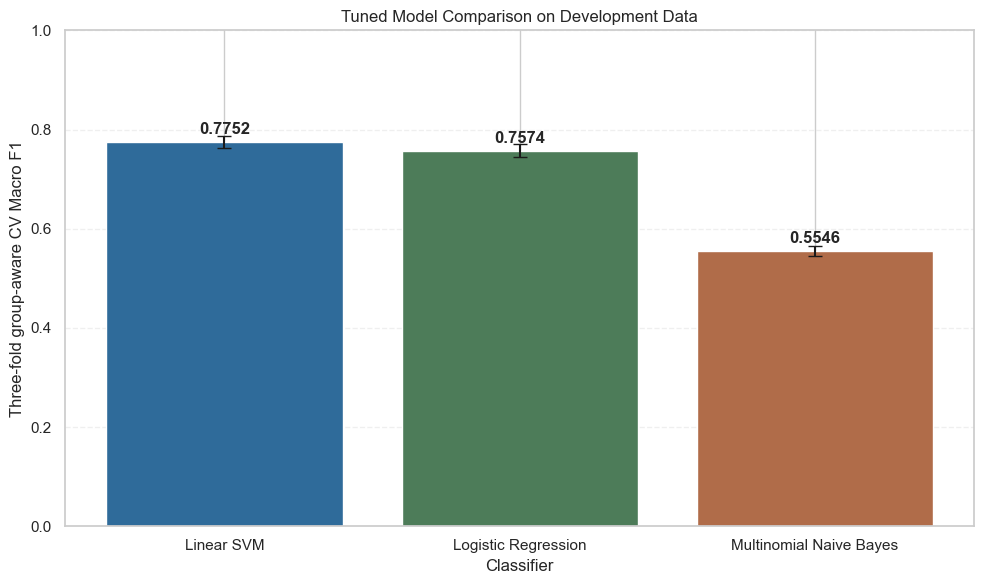

Saved: reports\figures\final_model_comparison.png


In [9]:
comparison_plot_df = tuning_results.copy()
short_model_names = comparison_plot_df["model"].str.replace("TF-IDF + ", "", regex=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    short_model_names,
    comparison_plot_df["best_dev_cv_macro_f1"],
    yerr=comparison_plot_df["best_dev_cv_macro_f1_std"],
    capsize=5,
    color=["#2F6B9A", "#4D7C59", "#B06C49"],
)
ax.set_title("Tuned Model Comparison on Development Data")
ax.set_ylabel("Three-fold group-aware CV Macro F1")
ax.set_xlabel("Classifier")
ax.set_ylim(0.0, 1.0)
ax.grid(axis="y", linestyle="--", alpha=0.3)
for bar, score in zip(bars, comparison_plot_df["best_dev_cv_macro_f1"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
fig.tight_layout()
fig.savefig(MODEL_COMPARISON_PATH, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_COMPARISON_PATH.relative_to(PROJECT_ROOT)}")

## 8. Final Evaluation and Visualizations

The winning configuration is now fitted on the complete development set and evaluated once within this final notebook on the held-out internal test fold. Metrics include accuracy; macro and weighted precision, recall, and F1; and a per-class report. The confusion matrix uses the fitted classifier's `classes_` order, not a frequency-sorted label list. No row-level prediction is displayed or exported.

In [10]:
final_pipeline = clone(model_pipelines[winning_model_name]).set_params(**winning_parameters)
final_fit_start = time.perf_counter()
final_pipeline.fit(X_dev, y_dev)
final_fit_seconds = time.perf_counter() - final_fit_start

X_test = final_test_df["clean_complaint_text"]
y_test = final_test_df["product"]
final_predictions = final_pipeline.predict(X_test)
class_order = list(final_pipeline.classes_)

assert set(class_order) == set(LOCKED_CATEGORIES)
assert set(final_predictions).issubset(set(class_order))
assert group_overlap_count == 0

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test, final_predictions, average="macro", zero_division=0
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test, final_predictions, average="weighted", zero_division=0
)
final_metrics = {
    "Accuracy": float(accuracy_score(y_test, final_predictions)),
    "Macro Precision": float(macro_precision),
    "Macro Recall": float(macro_recall),
    "Macro F1": float(macro_f1),
    "Weighted Precision": float(weighted_precision),
    "Weighted Recall": float(weighted_recall),
    "Weighted F1": float(weighted_f1),
}
final_metrics_table = pd.DataFrame(
    {"metric": final_metrics.keys(), "value": final_metrics.values()}
)
display(final_metrics_table.round(4))

class_precision, class_recall, class_f1, class_support = precision_recall_fscore_support(
    y_test,
    final_predictions,
    labels=class_order,
    average=None,
    zero_division=0,
)
final_per_class_metrics = pd.DataFrame(
    {
        "product": class_order,
        "precision": class_precision,
        "recall": class_recall,
        "f1": class_f1,
        "support": class_support.astype(int),
    }
).set_index("product")
display(final_per_class_metrics.round(4))
print(f"Final fit runtime: {final_fit_seconds:.2f} seconds")
print("Predictions remain in memory only and are not exported.")

,metric,value
0,Accuracy,0.8764
1,Macro Precision,0.7816
2,Macro Recall,0.7836
3,Macro F1,0.7817
4,Weighted Precision,0.8780
5,Weighted Recall,0.8764
6,Weighted F1,0.8769


,precision,recall,f1,support
product,,,,
Checking or savings account,0.7660,0.8411,0.8018,428
Credit card,0.7278,0.7751,0.7507,507
Credit reporting or other personal consumer reports,0.9437,0.9298,0.9367,4328
Debt collection,0.7481,0.7586,0.7533,783
"Money transfer, virtual currency, or money service",0.6721,0.5694,0.6165,144
Mortgage,0.8596,0.8644,0.8620,177
Student loan,0.8425,0.8492,0.8458,126
Vehicle loan or lease,0.6930,0.6810,0.6870,116


Final fit runtime: 11.22 seconds
Predictions remain in memory only and are not exported.


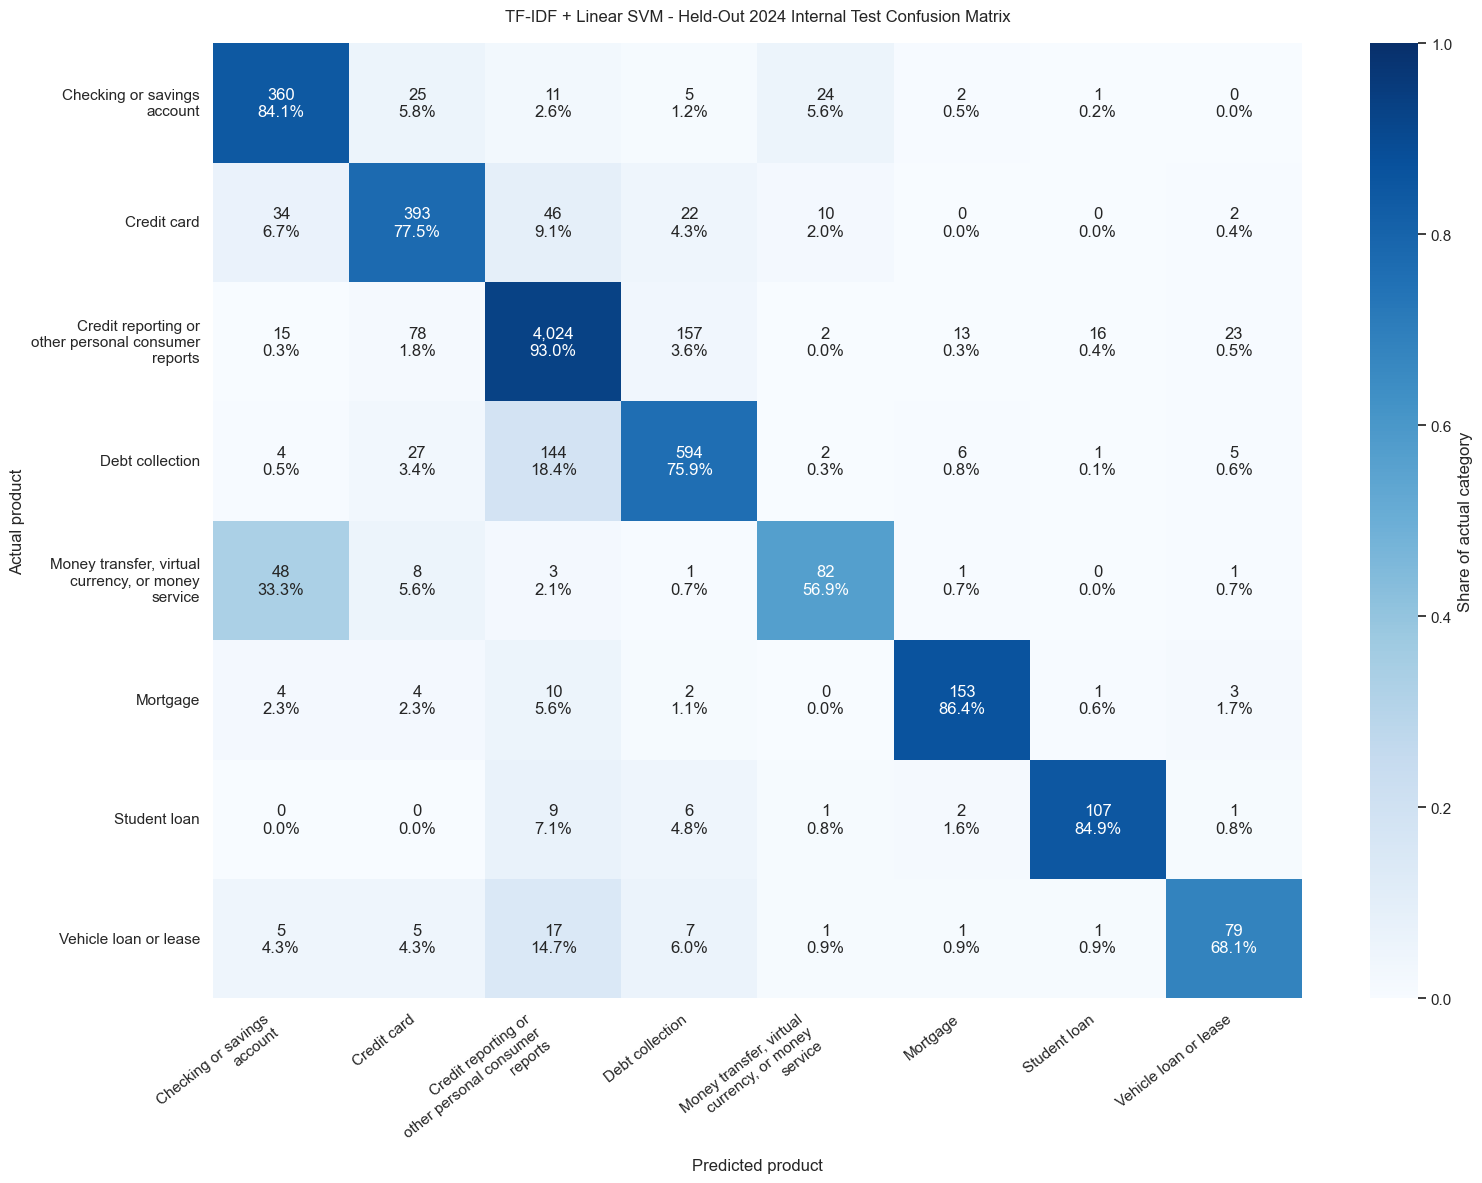

Saved: reports\figures\final_confusion_matrix.png
Confusion-matrix class order: ['Checking or savings account', 'Credit card', 'Credit reporting or other personal consumer reports', 'Debt collection', 'Money transfer, virtual currency, or money service', 'Mortgage', 'Student loan', 'Vehicle loan or lease']


In [11]:
confusion_counts = confusion_matrix(y_test, final_predictions, labels=class_order)
row_totals = confusion_counts.sum(axis=1, keepdims=True)
confusion_rates = np.divide(
    confusion_counts,
    row_totals,
    out=np.zeros_like(confusion_counts, dtype=float),
    where=row_totals != 0,
)
annotations = np.empty_like(confusion_counts, dtype=object)
for row_index in range(confusion_counts.shape[0]):
    for column_index in range(confusion_counts.shape[1]):
        annotations[row_index, column_index] = (
            f"{confusion_counts[row_index, column_index]:,}\n"
            f"{confusion_rates[row_index, column_index]:.1%}"
        )

wrapped_labels = [textwrap.fill(label, 23) for label in class_order]
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    confusion_rates,
    annot=annotations,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=wrapped_labels,
    yticklabels=wrapped_labels,
    cbar_kws={"label": "Share of actual category"},
    ax=ax,
)
ax.set_title(
    f"{winning_model_name} - Held-Out 2024 Internal Test Confusion Matrix",
    pad=16,
)
ax.set_xlabel("Predicted product")
ax.set_ylabel("Actual product")
ax.tick_params(axis="x", labelrotation=38)
for tick_label in ax.get_xticklabels():
    tick_label.set_horizontalalignment("right")
ax.tick_params(axis="y", labelrotation=0)
fig.tight_layout()
fig.savefig(CONFUSION_MATRIX_PATH, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {CONFUSION_MATRIX_PATH.relative_to(PROJECT_ROOT)}")
print(f"Confusion-matrix class order: {class_order}")

In [12]:
ranked_categories = final_per_class_metrics.sort_values("f1", ascending=False)
strongest_categories = ranked_categories.head(3).copy()
weakest_categories = ranked_categories.tail(3).sort_values("f1").copy()

print("Three strongest categories by held-out internal-test F1:")
display(strongest_categories.round(4))
print("Three weakest categories by held-out internal-test F1:")
display(weakest_categories.round(4))

Three strongest categories by held-out internal-test F1:


,precision,recall,f1,support
product,,,,
Credit reporting or other personal consumer reports,0.9437,0.9298,0.9367,4328
Mortgage,0.8596,0.8644,0.8620,177
Student loan,0.8425,0.8492,0.8458,126


Three weakest categories by held-out internal-test F1:


,precision,recall,f1,support
product,,,,
"Money transfer, virtual currency, or money service",0.6721,0.5694,0.6165,144
Vehicle loan or lease,0.6930,0.6810,0.6870,116
Credit card,0.7278,0.7751,0.7507,507


## 9. Discussion and Critical Analysis

### Why Linear SVM performed best

The winning **Linear SVM** is well matched to TF-IDF's sparse, high-dimensional representation. Complaint categories often have discriminative terms and short phrases, so a maximum-margin linear boundary can combine many weak lexical signals without requiring dense features. In this experiment, `C=0.5` supplied moderate regularization and the selected `(1, 2)` n-gram range added phrase-level evidence; these settings should not be treated as universal.

### Category-level performance

The aggregate ranking above identifies the strongest and weakest categories without exposing any narrative. Credit reporting or other personal consumer reports was strongest (0.9367 F1), followed by Mortgage (0.8620) and Student loan (0.8458). Money transfer, virtual currency, or money service was weakest (0.6165), followed by Vehicle loan or lease (0.6870) and Credit card (0.7507). High-support categories have more examples from which to learn stable vocabulary. Smaller or semantically overlapping categories are harder: money-transfer language can overlap checking-account language, debt-collection language can overlap credit-reporting language, and vehicle-loan complaints may mention both lending and reporting. Low support also makes per-class estimates less stable.

### Imbalance and metric interpretation

The class distribution is dominated by credit-reporting complaints. Accuracy and Weighted F1 therefore give that large, relatively strong class much more influence. Macro F1 gives each category equal weight, so it falls when smaller categories perform poorly. This is why Macro F1 is the primary selection metric and why per-class precision, recall, F1, and support are necessary. Class weighting helps Logistic Regression and Linear SVM respond to imbalance, but it cannot create missing examples or remove label ambiguity.

### Duplicate-leakage data cascade

The duplicate problem formed a data cascade: repeated complaint text crossed the original row-level split, placing identical normalized narratives in training and test and inflating internal evaluation. Conflicting-label removal, same-label deduplication, hash-based grouping, group-aware splitting, and explicit overlap assertions corrected this exact-duplicate issue; the old results remain documented only as superseded evidence. The SHA-256 grouping policy detects exact normalized-text matches only and may miss paraphrased or semantically near-duplicate narratives. A future audit could use embedding similarity to identify this residual risk, but it is not implemented here.

### Technical debt

Current technical debt includes preprocessing logic still concentrated in the notebook, dependency and environment management, product-taxonomy versioning, ambiguous historical labels, the lack of an out-of-time evaluation, and selection bias because only complaints with available narratives are included.

Before operational use, additional work would include probability calibration, business-approved error costs, human-review workflow design, privacy and security review, monitoring, and drift detection.

### No Free Lunch Theorem

No algorithm is best for every dataset. The selected winner is best only among these three candidates for this local 2024 sample, light-cleaning policy, TF-IDF representation, eight-category scope, duplicate policy, grouped split design, search grids, and Macro F1 objective. A different label taxonomy, time period, feature representation, cost function, or data source could favor another model. These results support an internal prototype, not a claim of production readiness.

## 10. Future Work and Reproducibility Summary

A future experiment could compare the TF-IDF baseline with DistilBERT or another Transformer. Contextual embeddings may better distinguish complaints whose meaning depends on word order or broader context. The costs are substantially greater computation, more tuning, more complex deployment and monitoring, and lower interpretability. No Transformer is implemented here.

The protected 2025 CFPB file should remain reserved and unused until a dedicated, pre-specified out-of-time evaluation. That later test would measure temporal transfer after the category scope, cleaning, duplicate policy, model, and decision rules are locked. It must not be used for iterative model selection.

In [13]:
total_runtime_seconds = baseline_runtime_seconds + tuning_runtime_seconds + final_fit_seconds
used_2025 = any("2025" in path.name for path in INPUT_FILES_USED)
assert not used_2025
assert MODEL_COMPARISON_PATH.is_file()
assert CONFUSION_MATRIX_PATH.is_file()

final_model_summary = pd.DataFrame(
    [
        ("Winning model", winning_model_name),
        ("Best parameters", str(winning_parameters)),
        ("Development CV Macro F1", f"{winning_dev_macro_f1:.4f}"),
        ("Held-out Accuracy", f"{final_metrics['Accuracy']:.4f}"),
        ("Held-out Macro F1", f"{final_metrics['Macro F1']:.4f}"),
        ("Held-out Weighted F1", f"{final_metrics['Weighted F1']:.4f}"),
    ],
    columns=["item", "value"],
)

reproducibility_summary = pd.DataFrame(
    [
        ("Input data source", acquisition_result["source"]),
        ("Input CSV SHA-256", acquisition_result["checksum_sha256"]),
        ("Rows after duplicate remediation", f"{len(remediated_df):,}"),
        ("Development rows", f"{len(development_df):,}"),
        ("Held-out internal test rows", f"{len(final_test_df):,}"),
        ("Development/test group overlap", str(group_overlap_count)),
        ("Modeling runtime", f"{total_runtime_seconds / 60:.2f} minutes"),
        ("2025 data used", "No"),
    ],
    columns=["item", "value"],
)

print("Final Model Summary")
display(final_model_summary)
print("Reproducibility Summary")
display(reproducibility_summary)
print(
    "Reproducibility checks passed. The notebook used only the validated "
    "2024 CFPB raw-input CSV."
)

Final Model Summary


,item,value
0,Winning model,TF-IDF + Linear SVM
1,Best parameters,"{'classifier__C': 0.5, 'tfidf__ngram_range': (1, 2)}"
2,Development CV Macro F1,0.7752
3,Held-out Accuracy,0.8764
4,Held-out Macro F1,0.7817
5,Held-out Weighted F1,0.8769


Reproducibility Summary


,item,value
0,Input data source,existing local CSV
1,Input CSV SHA-256,30d4f65452d2b75d9fe602df5ccf847395e1318d2b9ad0d37d6e78f08d738dad
2,Rows after duplicate remediation,"33,042"
3,Development rows,"26,433"
4,Held-out internal test rows,"6,609"
5,Development/test group overlap,0
6,Modeling runtime,9.86 minutes
7,2025 data used,No


Reproducibility checks passed. The notebook used only the validated 2024 CFPB raw-input CSV.
